In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import seaborn as sns

import argparse
from pathlib import Path

In [1]:
def create_calibration_plot(y_true, y_prob, n_bins=100, title="Calibration Plot", save_path=None):
    """
    Create a calibration plot (reliability diagram) for binary classification.
    
    Parameters:
    -----------
    y_true : array-like
        True binary labels (0 or 1)
    y_prob : array-like
        Predicted probabilities for the positive class
    n_bins : int
        Number of bins to use for calibration
    title : str
        Title for the plot
    save_path : str, optional
        Path to save the figure
    
    Returns:
    --------
    dict : Dictionary containing calibration metrics
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    # Calculate Brier score manually (mean squared difference between predicted probabilities and actual outcomes)
    brier_score = np.mean((y_prob - y_true) ** 2)
    
    # Manual calibration calculation for all bins
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_true_fractions = []
    bin_pred_means = []
    bin_counts = []
    
    # Calculate Expected Calibration Error (ECE) and bin statistics
    ece = 0
    for i in range(n_bins):
        # Create mask for current bin
        if i == n_bins - 1:  # Include right edge in last bin
            mask = (y_prob >= bin_edges[i]) & (y_prob <= bin_edges[i+1])
        else:
            mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i+1])
        
        n_in_bin = mask.sum()
        bin_counts.append(n_in_bin)
        
        if n_in_bin > 0:
            # Fraction of positives in this bin (actual frequency)
            bin_acc = y_true[mask].mean()
            # Mean predicted probability in this bin
            bin_conf = y_prob[mask].mean()
            # Weight by number of samples
            bin_weight = n_in_bin / len(y_prob)
            ece += bin_weight * abs(bin_acc - bin_conf)
            bin_true_fractions.append(bin_acc)
            bin_pred_means.append(bin_conf)
        else:
            bin_true_fractions.append(np.nan)
            bin_pred_means.append(np.nan)
    
    # Calculate confusion matrix values using 0.5 threshold
    y_pred = (y_prob >= 0.5).astype(int)
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    tp = np.sum((y_pred == 1) & (y_true == 1))
    
    # Create the plot
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))
    
    # Main calibration plot (ax1)
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated', alpha=0.7)
    
    # Plot bars for ALL bins
    bin_width = 1.0 / n_bins
    bar_width = bin_width * 0.8  # 80% of bin width to leave gaps
    
    for i in range(n_bins):
        if bin_counts[i] > 0:
            # Bin with data - solid bar
            ax1.bar(bin_centers[i], bin_true_fractions[i], 
                   width=bar_width, alpha=0.8, color='blue', 
                   edgecolor='darkblue', linewidth=1.5,
                   label='Model calibration' if i == 0 else None)
        else:
            # Empty bin - show as very faint bar at zero
            ax1.bar(bin_centers[i], 0, 
                   width=bar_width, alpha=0.1, color='gray', 
                   edgecolor='gray', linewidth=0.5,
                   label='Empty bins' if i == 0 else None)
    
    ax1.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax1.set_ylabel('Fraction of Positives', fontsize=12)
    ax1.set_title(f'{title}', fontsize=14)
    ax1.legend(loc='upper left', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])
    ax1.set_aspect('equal')
    
    # Zoomed calibration plot (ax2) - focusing on [0.5, 1.0]
    lo, hi = 0.5, 1.0
    n_bins_zoom = n_bins
    
    # Manual calibration for zoom window
    bin_edges_zoom = np.linspace(lo, hi, n_bins_zoom + 1)
    bin_centers_zoom = (bin_edges_zoom[:-1] + bin_edges_zoom[1:]) / 2
    bin_true_fractions_zoom = []
    bin_counts_zoom = []
    
    ece_zoom = 0
    total_in_zoom = np.sum((y_prob >= lo) & (y_prob <= hi))
    
    for i in range(n_bins_zoom):
        # Create mask for current bin
        if i == n_bins_zoom - 1:  # Include right edge in last bin
            mask = (y_prob >= bin_edges_zoom[i]) & (y_prob <= bin_edges_zoom[i+1])
        else:
            mask = (y_prob >= bin_edges_zoom[i]) & (y_prob < bin_edges_zoom[i+1])
        
        n_in_bin = mask.sum()
        bin_counts_zoom.append(n_in_bin)
        
        if n_in_bin > 0:
            bin_acc = y_true[mask].mean()
            bin_conf = y_prob[mask].mean()
            if total_in_zoom > 0:
                bin_weight = n_in_bin / total_in_zoom
                ece_zoom += bin_weight * abs(bin_acc - bin_conf)
            bin_true_fractions_zoom.append(bin_acc)
        else:
            bin_true_fractions_zoom.append(np.nan)
    
    ax2.plot([lo, hi], [lo, hi], 'k--', alpha=0.7, label='Perfectly calibrated')
    
    # Plot bars for zoom window
    bar_width_zoom = (hi - lo) / n_bins_zoom * 0.8
    
    for i in range(n_bins_zoom):
        if bin_counts_zoom[i] > 0:
            ax2.bar(bin_centers_zoom[i], bin_true_fractions_zoom[i], 
                   width=bar_width_zoom, alpha=0.8, color='blue', 
                   edgecolor='darkblue', linewidth=1.5,
                   label='Model calibration' if i == 0 else None)
        else:
            ax2.bar(bin_centers_zoom[i], lo, 
                   width=bar_width_zoom, alpha=0.1, color='gray', 
                   edgecolor='gray', linewidth=0.5,
                   label='Empty bins' if i == 0 else None)
    
    if total_in_zoom > 0:
        ax2.text(0.51, 0.52, f"ECE (0.5–1.0): {ece_zoom:.3f}", 
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    else:
        ax2.text(0.75, 0.75, "No samples in [0.5, 1.0]", ha='center', va='center')
    
    ax2.set_xlim(lo, hi)
    ax2.set_ylim(lo, hi)
    ax2.set_aspect('equal')
    ax2.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax2.set_ylabel('Fraction of Positives', fontsize=12)
    ax2.set_title('Calibration (0.5–1.0)', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='lower right', fontsize=11)
    
    # Distribution histogram (ax3)
    ax3.hist(y_prob[y_true == 0], bins=30, alpha=0.5, label='Negative class',
            color='red', density=True)
    ax3.hist(y_prob[y_true == 1], bins=30, alpha=0.5, label='Positive class',
            color='green', density=True)
    ax3.set_xlabel('Predicted Probability', fontsize=12)
    ax3.set_ylabel('Density', fontsize=12)
    ax3.set_title('Distribution of Predicted Probabilities', fontsize=14)
    ax3.legend(loc='upper center', fontsize=11)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()
    
    # Return calibration metrics
    metrics = {
        'brier_score': brier_score,
        'ece': ece,
        'bin_centers': bin_centers,
        'bin_true_fractions': bin_true_fractions,
        'bin_counts': bin_counts
    }
    
    return metrics

In [2]:
import pandas as pd
import numpy as np
import os

def create_detailed_calibration_analysis(df_path, output_dir=None, title="Model Calibration Analysis", n_bins=100):
    """
    Create comprehensive calibration analysis from prediction CSV file.
    
    Parameters:
    -----------
    df_path : str
        Path to the predictions CSV file
    output_dir : str, optional
        Directory to save the plots
    title : str
        Title for the calibration plot
    n_bins : int
        Number of bins to use for calibration (default=20)
    
    Returns:
    --------
    dict : Dictionary containing calibration metrics
    """
    
    # Load the data
    df = pd.read_csv(df_path)
    
    print("Data loaded successfully!")
    print(f"Total samples: {len(df)}")
    print(f"Class distribution: {df['true_label'].value_counts().to_dict()}")
    
    # Extract necessary columns
    y_true = df['true_label'].values
    y_prob = df['prob_class_1'].values  # Probability for positive class
    
    # Create output directory if it doesn't exist
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
    
    # Create main calibration plot with specified n_bins
    print(f"\nCreating calibration plot with {n_bins} bins...")
    save_path = f"{output_dir}/calibration_plot.png" if output_dir else None
    metrics = create_calibration_plot(y_true, y_prob, n_bins=n_bins, 
                                     title=title,
                                     save_path=save_path)
    
    # Print calibration metrics
    print("\n" + "="*50)
    print("CALIBRATION METRICS:")
    print("="*50)
    print(f"Brier Score: {metrics['brier_score']:.4f}")
    print(f"Expected Calibration Error (ECE): {metrics['ece']:.4f}")
    
    # Calculate additional metrics
    from sklearn.metrics import log_loss, roc_auc_score
    log_loss_value = log_loss(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)
    
    print(f"Log Loss: {log_loss_value:.4f}")
    print(f"AUC-ROC: {auc_score:.4f}")
    
    # Interpretation
    print("\nInterpretation:")
    if metrics['brier_score'] < 0.1:
        print("✓ Excellent calibration (Brier < 0.1)")
    elif metrics['brier_score'] < 0.2:
        print("✓ Good calibration (Brier < 0.2)")
    elif metrics['brier_score'] < 0.3:
        print("⚠ Fair calibration (Brier < 0.3)")
    else:
        print("✗ Poor calibration (Brier ≥ 0.3)")
    
    if metrics['ece'] < 0.05:
        print("✓ Excellent ECE (< 0.05)")
    elif metrics['ece'] < 0.1:
        print("✓ Good ECE (< 0.1)")
    else:
        print("⚠ High ECE (≥ 0.1) - Model confidence doesn't match accuracy")
    
    # Additional analysis: confidence vs accuracy by bins
    print("\n" + "="*50)
    print("CONFIDENCE vs ACCURACY BY BINS:")
    print("="*50)
    print(f"{'Bin Range':<15} {'Samples':>8} {'Avg Conf':>10} {'Accuracy':>10} {'Gap':>8} {'Status'}")
    print("-" * 70)
    
    # Use the same bin edges as in the plot
    bin_edges = np.linspace(0, 1, n_bins + 1)
    
    total_weighted_gap = 0
    for i in range(n_bins):
        if i == n_bins - 1:  # Include right edge in last bin
            mask = (y_prob >= bin_edges[i]) & (y_prob <= bin_edges[i+1])
        else:
            mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i+1])
        
        if mask.sum() > 0:
            bin_acc = y_true[mask].mean()
            bin_conf = y_prob[mask].mean()
            bin_count = mask.sum()
            gap = abs(bin_conf - bin_acc)
            
            # Determine status
            if gap < 0.05:
                status = "✓ Well calibrated"
            elif gap < 0.1:
                status = "⚠ Slightly off"
            else:
                status = "✗ Poorly calibrated"
            
            print(f"[{bin_edges[i]:.2f}-{bin_edges[i+1]:.2f}]    "
                  f"{bin_count:>8d} "
                  f"{bin_conf:>10.3f} "
                  f"{bin_acc:>10.3f} "
                  f"{gap:>8.3f}  {status}")
            
            # Track weighted gap
            weight = bin_count / len(y_prob)
            total_weighted_gap += weight * gap
        else:
            print(f"[{bin_edges[i]:.2f}-{bin_edges[i+1]:.2f}]    "
                  f"{'0':>8} "
                  f"{'-':>10} "
                  f"{'-':>10} "
                  f"{'-':>8}  (empty bin)")
    
    print("-" * 70)
    print(f"Weighted Average Gap (ECE): {total_weighted_gap:.4f}")
    
    # Summary statistics
    print("\n" + "="*50)
    print("PREDICTION DISTRIBUTION SUMMARY:")
    print("="*50)
    
    # Confidence statistics
    print(f"Mean predicted probability: {y_prob.mean():.3f}")
    print(f"Std predicted probability: {y_prob.std():.3f}")
    print(f"Min predicted probability: {y_prob.min():.3f}")
    print(f"Max predicted probability: {y_prob.max():.3f}")
    
    # Percentiles
    percentiles = [10, 25, 50, 75, 90]
    print("\nPrediction percentiles:")
    for p in percentiles:
        print(f"  {p}th percentile: {np.percentile(y_prob, p):.3f}")
    
    # Predictions by range
    print(f"\nPredictions by range:")
    print(f"  [0.0-0.1]: {np.sum((y_prob >= 0.0) & (y_prob < 0.1)):>6d} ({100*np.mean((y_prob >= 0.0) & (y_prob < 0.1)):.1f}%)")
    print(f"  [0.1-0.5]: {np.sum((y_prob >= 0.1) & (y_prob < 0.5)):>6d} ({100*np.mean((y_prob >= 0.1) & (y_prob < 0.5)):.1f}%)")
    print(f"  [0.5-0.9]: {np.sum((y_prob >= 0.5) & (y_prob < 0.9)):>6d} ({100*np.mean((y_prob >= 0.5) & (y_prob < 0.9)):.1f}%)")
    print(f"  [0.9-1.0]: {np.sum((y_prob >= 0.9) & (y_prob <= 1.0)):>6d} ({100*np.mean((y_prob >= 0.9) & (y_prob <= 1.0)):.1f}%)")
    
    # Add all metrics to return dictionary
    metrics['log_loss'] = log_loss_value
    metrics['auc_roc'] = auc_score
    metrics['mean_confidence'] = y_prob.mean()
    metrics['std_confidence'] = y_prob.std()
    
    return metrics

# Example usage:
# metrics = create_detailed_calibration_analysis('predictions.csv', output_dir='plots', n_bins=20)

In [6]:
test_csv_path = "/projects/retprogression/rgarridogarcia/clean_gradable_swinv2_resolution1024_oversample50_RetinaCropped_BrightnessFilter/test_results_20250917_085511/predictions_best_balanced_acc_model.csv"
val_csv_path = "/projects/retprogression/rgarridogarcia/clean_gradable_swinv2_resolution1024_oversample50_RetinaCropped_BrightnessFilter/val_results_20250917_085511/predictions_best_balanced_acc_model.csv"
train_csv_path = "/projects/retprogression/gradable_dr_train.csv"
complete_csv_path = "/projects/retprogression/rgarridogarcia/validation_results_20250917_082610/predictions_best_balanced_acc_model.csv"
print('Train')
display(pd.read_csv(train_csv_path))
print('Validation')
display(pd.read_csv(val_csv_path))
print('Test')
display(pd.read_csv(test_csv_path))
print('Complete')
display(pd.read_csv(complete_csv_path))

# Read the CSV files
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)
complete_df = pd.read_csv(complete_csv_path)



Train


,Unnamed: 0,ID,gradable_binary_DR,JVN_PATIENT_ID
0,5,27756,0,10000
1,6,27757,0,10000
2,7,27758,0,10000
3,8,27759,0,10000
4,9,27760,0,10000
...,...,...,...,...
31022,52122,84091,0,54082
31023,52123,84092,0,54082
31024,52124,84093,0,54082
31025,52125,84094,0,54082


Validation


,image_id,original_index,true_label,predicted_label,prob_class_0,prob_class_1,logit_0,logit_1,logit_margin,correct
0,53487,0,1,1,0.009065,0.990935,-2.078633,2.615591,4.694224,True
1,53490,1,1,1,0.011555,0.988445,-1.938928,2.510112,4.449039,True
2,54849,2,1,1,0.015803,0.984197,-2.065145,2.066480,4.131625,True
3,54850,3,1,1,0.037309,0.962691,-1.681198,1.569291,3.250489,True
4,54851,4,1,1,0.056336,0.943664,-1.682703,1.135739,2.818442,True
...,...,...,...,...,...,...,...,...,...,...
4111,603289,4111,1,0,0.769370,0.230630,0.379178,-0.825578,-1.204757,False
4112,603293,4112,1,0,0.563002,0.436999,-0.274649,-0.528002,-0.253353,False
4113,603566,4113,1,0,0.643577,0.356423,0.238687,-0.352237,-0.590924,False
4114,603812,4114,1,0,0.994368,0.005632,2.962723,-2.210930,-5.173653,False


Test


,image_id,original_index,true_label,predicted_label,prob_class_0,prob_class_1,logit_0,logit_1,logit_margin,correct
0,50791,0,0,0,0.996512,0.003488,2.774016,-2.880965,-5.654981,True
1,50795,1,0,0,0.993287,0.006713,2.450392,-2.546562,-4.996953,True
2,51743,2,1,0,0.941079,0.058921,1.368925,-1.401903,-2.770828,False
3,51747,3,1,0,0.761702,0.238298,0.390829,-0.771204,-1.162033,False
4,52530,4,1,1,0.000884,0.999116,-3.742759,3.287388,7.030147,True
...,...,...,...,...,...,...,...,...,...,...
4277,602719,4277,1,1,0.023296,0.976704,-2.630222,1.105672,3.735895,True
4278,602720,4278,1,1,0.098331,0.901669,-1.755961,0.459948,2.215909,True
4279,602723,4279,1,1,0.011565,0.988435,-2.809085,1.639072,4.448157,True
4280,602724,4280,1,1,0.042707,0.957293,-2.071496,1.038261,3.109756,True


Complete


,image_id,original_index,true_label,predicted_label,prob_class_0,prob_class_1,logit_0,logit_1,logit_margin,correct
0,49430,4,1,0,0.988088,0.011912,2.558281,-1.859921,-4.418202,False
1,49431,5,1,0,0.940674,0.059326,1.463674,-1.299875,-2.763549,False
2,49432,6,1,0,0.777219,0.222781,0.667957,-0.581575,-1.249532,False
3,49433,7,1,0,0.816293,0.183707,0.717269,-0.774165,-1.491434,False
4,49434,8,1,1,0.267397,0.732603,-0.634180,0.373691,1.007871,True
...,...,...,...,...,...,...,...,...,...,...
106874,604039,134517,1,0,0.778855,0.221145,0.071496,-1.187510,-1.259006,False
106875,604041,134518,1,1,0.062554,0.937446,-1.923021,0.784110,2.707131,True
106876,604042,134519,1,0,0.833578,0.166423,0.208377,-1.402820,-1.611197,False
106877,604048,134520,1,1,0.021294,0.978706,-2.470074,1.357732,3.827806,True


ANALYZING TEST SET
Data loaded successfully!
Total samples: 4282
Class distribution: {1: 4176, 0: 106}

Creating calibration plot with 50 bins...
Plot saved to /projects/retprogression/rgarridogarcia/calibration_plots/calibration_plot.png


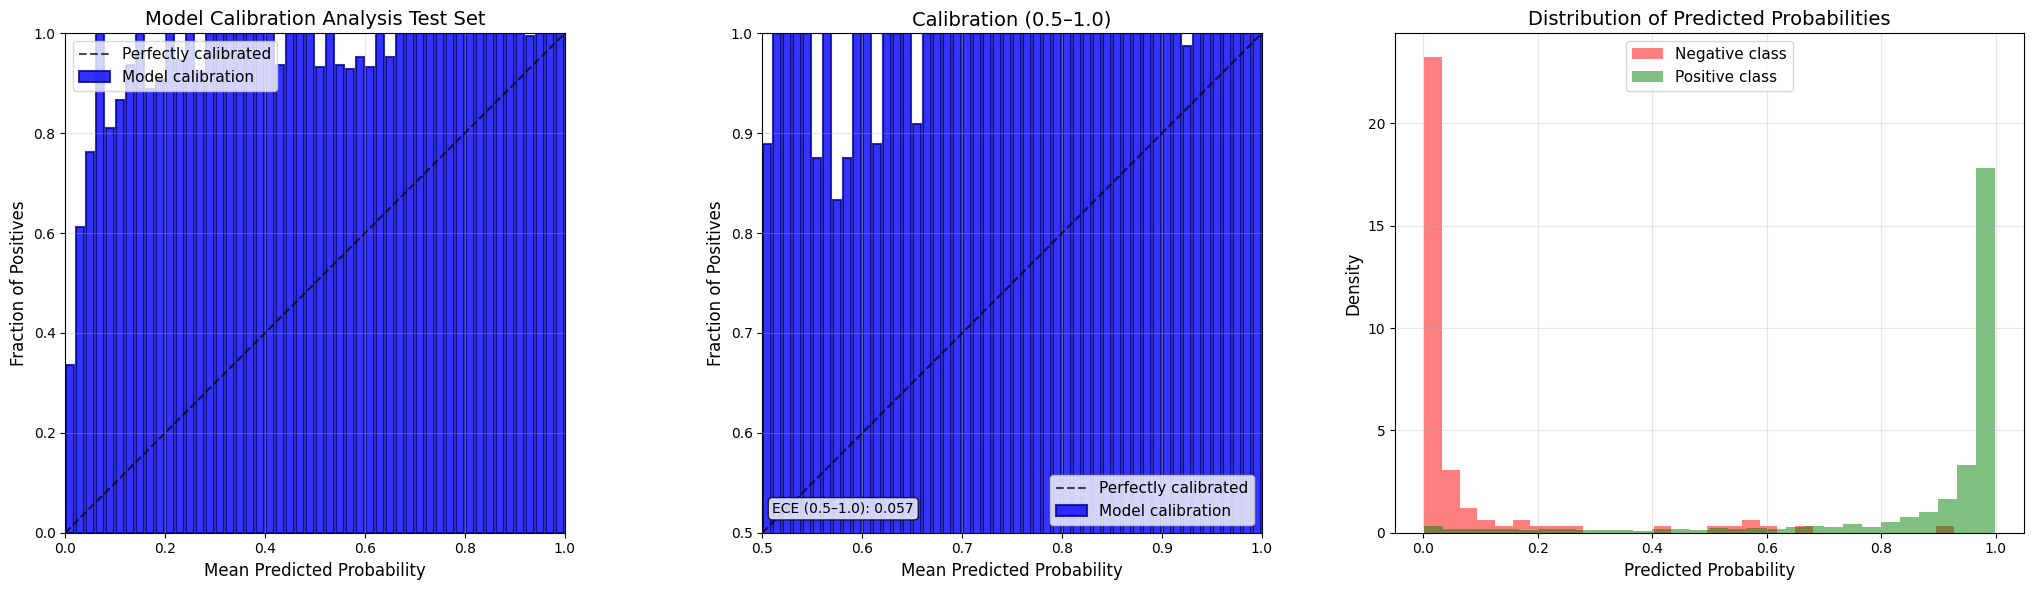


CALIBRATION METRICS:
Brier Score: 0.0641
Expected Calibration Error (ECE): 0.1146
Log Loss: 0.2251
AUC-ROC: 0.9834

Interpretation:
✓ Excellent calibration (Brier < 0.1)
⚠ High ECE (≥ 0.1) - Model confidence doesn't match accuracy

CONFIDENCE vs ACCURACY BY BINS:
Bin Range        Samples   Avg Conf   Accuracy      Gap Status
----------------------------------------------------------------------
[0.00-0.02]         104      0.008      0.337    0.328  ✗ Poorly calibrated
[0.02-0.04]          31      0.031      0.613    0.582  ✗ Poorly calibrated
[0.04-0.06]          21      0.048      0.762    0.713  ✗ Poorly calibrated
[0.06-0.08]          15      0.068      1.000    0.932  ✗ Poorly calibrated
[0.08-0.10]          21      0.089      0.810    0.721  ✗ Poorly calibrated
[0.10-0.12]          15      0.109      0.867    0.758  ✗ Poorly calibrated
[0.12-0.14]          16      0.128      0.938    0.810  ✗ Poorly calibrated
[0.14-0.16]          15      0.150      1.000    0.850  ✗ Poorly cali

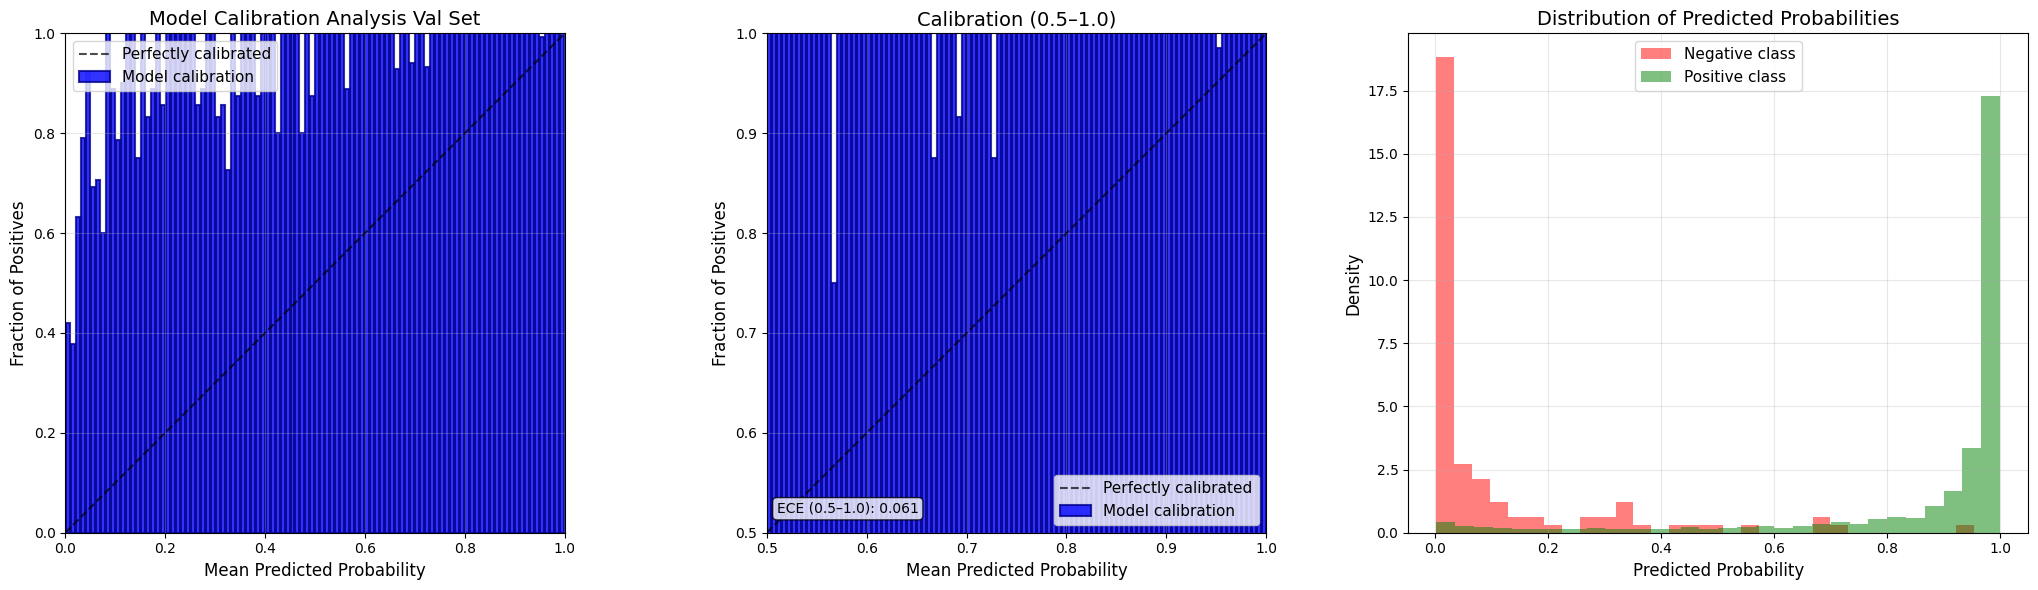


CALIBRATION METRICS:
Brier Score: 0.0708
Expected Calibration Error (ECE): 0.1228
Log Loss: 0.2485
AUC-ROC: 0.9735

Interpretation:
✓ Excellent calibration (Brier < 0.1)
⚠ High ECE (≥ 0.1) - Model confidence doesn't match accuracy

CONFIDENCE vs ACCURACY BY BINS:
Bin Range        Samples   Avg Conf   Accuracy      Gap Status
----------------------------------------------------------------------
[0.00-0.01]          50      0.006      0.420    0.414  ✗ Poorly calibrated
[0.01-0.02]          37      0.014      0.378    0.365  ✗ Poorly calibrated
[0.02-0.03]          19      0.024      0.632    0.607  ✗ Poorly calibrated
[0.03-0.04]          19      0.035      0.789    0.754  ✗ Poorly calibrated
[0.04-0.05]          13      0.044      0.923    0.879  ✗ Poorly calibrated
[0.05-0.06]          13      0.055      0.692    0.637  ✗ Poorly calibrated
[0.06-0.07]          17      0.065      0.706    0.641  ✗ Poorly calibrated
[0.07-0.08]          10      0.074      0.600    0.526  ✗ Poorly cali

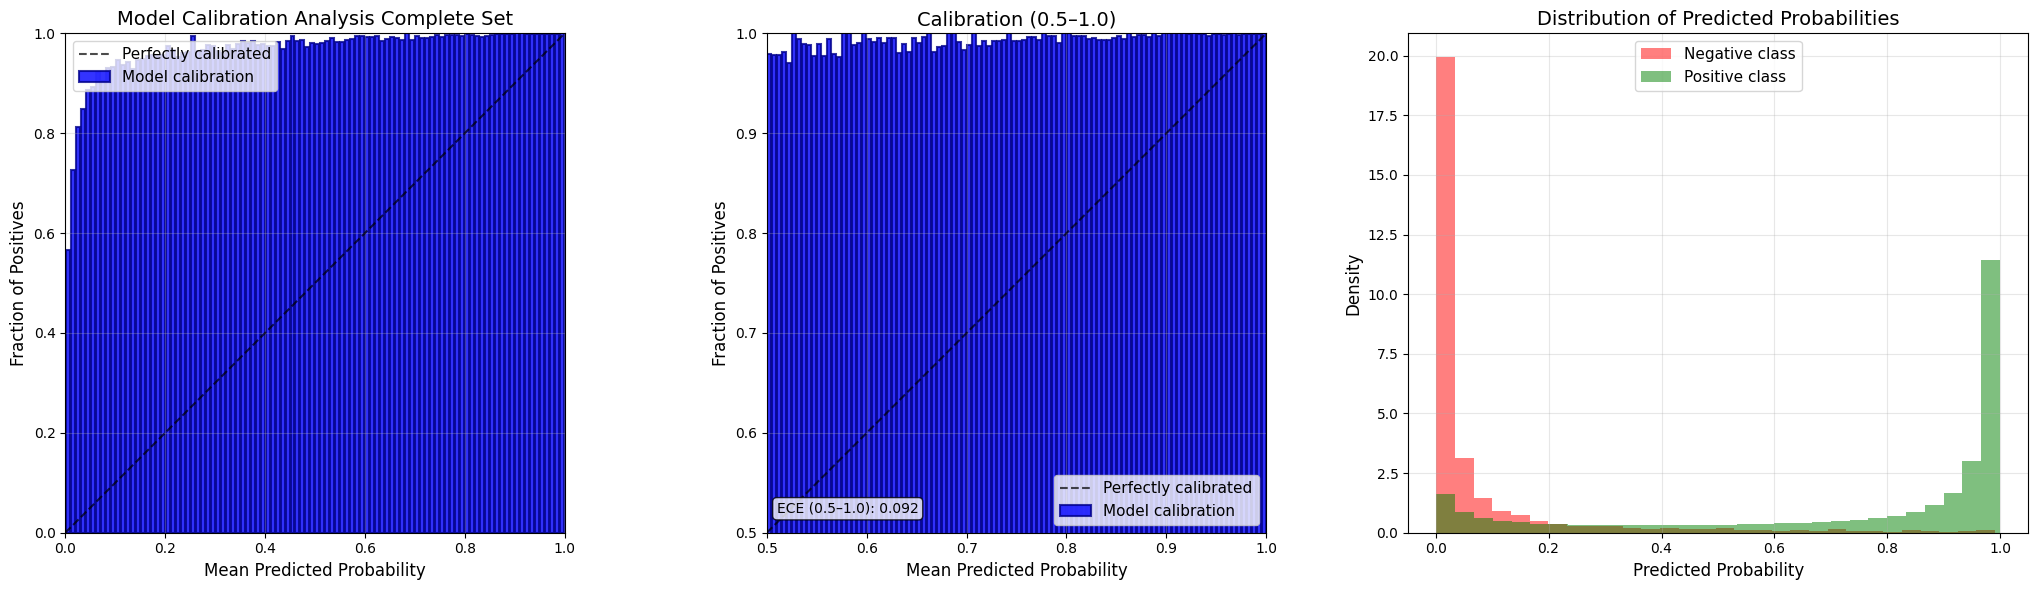


CALIBRATION METRICS:
Brier Score: 0.1817
Expected Calibration Error (ECE): 0.2580
Log Loss: 0.6215
AUC-ROC: 0.9368

Interpretation:
✓ Good calibration (Brier < 0.2)
⚠ High ECE (≥ 0.1) - Model confidence doesn't match accuracy

CONFIDENCE vs ACCURACY BY BINS:
Bin Range        Samples   Avg Conf   Accuracy      Gap Status
----------------------------------------------------------------------
[0.00-0.01]        2769      0.006      0.566    0.560  ✗ Poorly calibrated
[0.01-0.02]        2718      0.015      0.727    0.712  ✗ Poorly calibrated
[0.02-0.03]        1777      0.025      0.813    0.788  ✗ Poorly calibrated
[0.03-0.04]        1355      0.035      0.848    0.813  ✗ Poorly calibrated
[0.04-0.05]        1087      0.045      0.886    0.841  ✗ Poorly calibrated
[0.05-0.06]         907      0.055      0.892    0.837  ✗ Poorly calibrated
[0.06-0.07]         817      0.065      0.923    0.858  ✗ Poorly calibrated
[0.07-0.08]         749      0.075      0.904    0.829  ✗ Poorly calibrate

In [7]:
test_csv_path = "/projects/retprogression/rgarridogarcia/clean_gradable_swinv2_resolution1024_oversample50_RetinaCropped_BrightnessFilter/test_results_20250917_085511/predictions_best_balanced_acc_model.csv"
val_csv_path = "/projects/retprogression/rgarridogarcia/clean_gradable_swinv2_resolution1024_oversample50_RetinaCropped_BrightnessFilter/val_results_20250917_085511/predictions_best_balanced_acc_model.csv"
train_csv_path = "/projects/retprogression/gradable_dr_train.csv"
complete_csv_path = "/projects/retprogression/rgarridogarcia/validation_results_20250917_082610/predictions_best_balanced_acc_model.csv"
output_directory = "/projects/retprogression/rgarridogarcia/calibration_plots"

# Create output directory if it doesn't exist
import os
if output_directory and not os.path.exists(output_directory):
    os.makedirs(output_directory)
    
# Run calibration analysis for all three datasets
print("="*60)
print("ANALYZING TEST SET")
print("="*60)
test_metrics = create_detailed_calibration_analysis(
    test_csv_path, 
    output_directory, 
    title="Model Calibration Analysis Test Set",
    n_bins=50
)

print("\n\n" + "="*60)
print("ANALYZING VALIDATION SET")
print("="*60)
val_metrics = create_detailed_calibration_analysis(
    val_csv_path, 
    output_directory, 
    title="Model Calibration Analysis Val Set",
    n_bins=100
)

print("\n\n" + "="*60)
print("ANALYZING COMPLETE SET")
print("="*60)
complete_metrics = create_detailed_calibration_analysis(
    complete_csv_path, 
    output_directory, 
    title="Model Calibration Analysis Complete Set",
    n_bins=100
)

# Optional: Compare metrics across all sets
print("\n\n" + "="*60)
print("COMPARATIVE SUMMARY")
print("="*60)
print(f"{'Dataset':<15} {'Brier Score':>12} {'ECE':>8} {'AUC-ROC':>8} {'Log Loss':>10}")
print("-"*55)
print(f"{'Test Set':<15} {test_metrics['brier_score']:>12.4f} {test_metrics['ece']:>8.4f} {test_metrics['auc_roc']:>8.4f} {test_metrics['log_loss']:>10.4f}")
print(f"{'Validation Set':<15} {val_metrics['brier_score']:>12.4f} {val_metrics['ece']:>8.4f} {val_metrics['auc_roc']:>8.4f} {val_metrics['log_loss']:>10.4f}")
print(f"{'Complete Set':<15} {complete_metrics['brier_score']:>12.4f} {complete_metrics['ece']:>8.4f} {complete_metrics['auc_roc']:>8.4f} {complete_metrics['log_loss']:>10.4f}")

Data loaded successfully!
Total samples: 4282
Class distribution: {1: 4176, 0: 106}

Creating calibration plot...
Plot saved to /projects/retprogression/rgarridogarcia/calibration_plots/calibration_plot.png


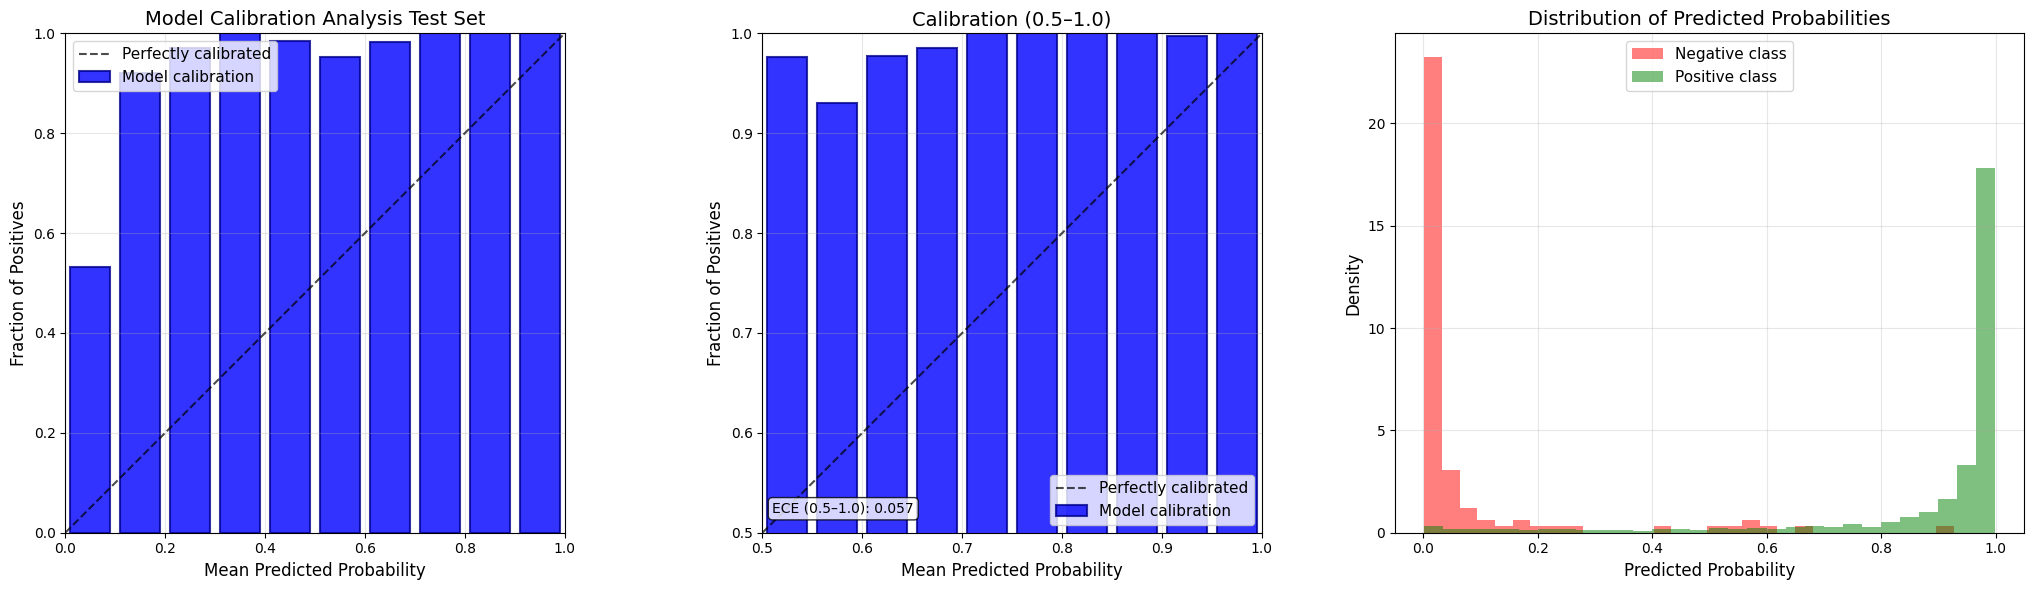


CALIBRATION METRICS:
Brier Score: 0.0641
Expected Calibration Error (ECE): 0.1146

Interpretation:
✓ Excellent calibration (Brier < 0.1)
⚠ High ECE (≥ 0.1) - Model confidence doesn't match accuracy

CONFIDENCE vs ACCURACY BY BINS:
Bin [0.00-0.05]: Samples= 148, Avg_Conf=0.016, Accuracy=0.419, Gap=0.403
Bin [0.05-0.10]: Samples=  44, Avg_Conf=0.076, Accuracy=0.909, Gap=0.834
Bin [0.10-0.15]: Samples=  39, Avg_Conf=0.124, Accuracy=0.923, Gap=0.799
Bin [0.15-0.20]: Samples=  36, Avg_Conf=0.172, Accuracy=0.917, Gap=0.745
Bin [0.20-0.25]: Samples=  39, Avg_Conf=0.227, Accuracy=0.974, Gap=0.747
Bin [0.25-0.30]: Samples=  28, Avg_Conf=0.275, Accuracy=0.964, Gap=0.690
Bin [0.30-0.35]: Samples=  29, Avg_Conf=0.322, Accuracy=1.000, Gap=0.678
Bin [0.35-0.40]: Samples=  22, Avg_Conf=0.377, Accuracy=1.000, Gap=0.623
Bin [0.40-0.45]: Samples=  37, Avg_Conf=0.426, Accuracy=0.973, Gap=0.547
Bin [0.45-0.50]: Samples=  31, Avg_Conf=0.474, Accuracy=1.000, Gap=0.526
Bin [0.50-0.55]: Samples=  42, Avg_Con

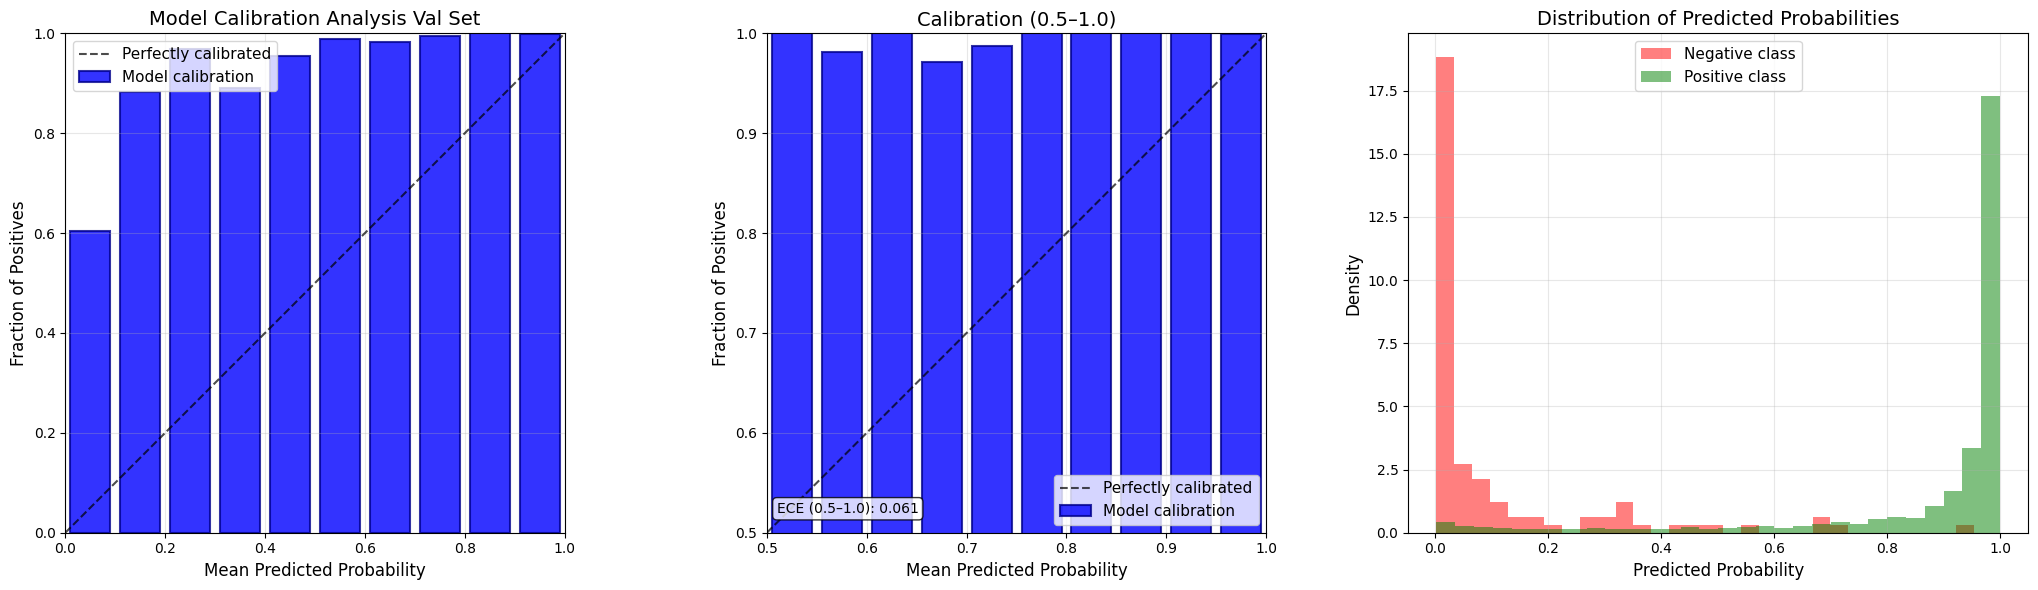


CALIBRATION METRICS:
Brier Score: 0.0708
Expected Calibration Error (ECE): 0.1228

Interpretation:
✓ Excellent calibration (Brier < 0.1)
⚠ High ECE (≥ 0.1) - Model confidence doesn't match accuracy

CONFIDENCE vs ACCURACY BY BINS:
Bin [0.00-0.05]: Samples= 138, Avg_Conf=0.018, Accuracy=0.536, Gap=0.518
Bin [0.05-0.10]: Samples=  59, Avg_Conf=0.073, Accuracy=0.763, Gap=0.690
Bin [0.10-0.15]: Samples=  41, Avg_Conf=0.121, Accuracy=0.854, Gap=0.733
Bin [0.15-0.20]: Samples=  35, Avg_Conf=0.174, Accuracy=0.914, Gap=0.740
Bin [0.20-0.25]: Samples=  32, Avg_Conf=0.228, Accuracy=1.000, Gap=0.772
Bin [0.25-0.30]: Samples=  31, Avg_Conf=0.279, Accuracy=0.935, Gap=0.656
Bin [0.30-0.35]: Samples=  35, Avg_Conf=0.326, Accuracy=0.829, Gap=0.503
Bin [0.35-0.40]: Samples=  29, Avg_Conf=0.376, Accuracy=0.966, Gap=0.590
Bin [0.40-0.45]: Samples=  33, Avg_Conf=0.428, Accuracy=0.970, Gap=0.542
Bin [0.45-0.50]: Samples=  33, Avg_Conf=0.473, Accuracy=0.939, Gap=0.467
Bin [0.50-0.55]: Samples=  37, Avg_Con

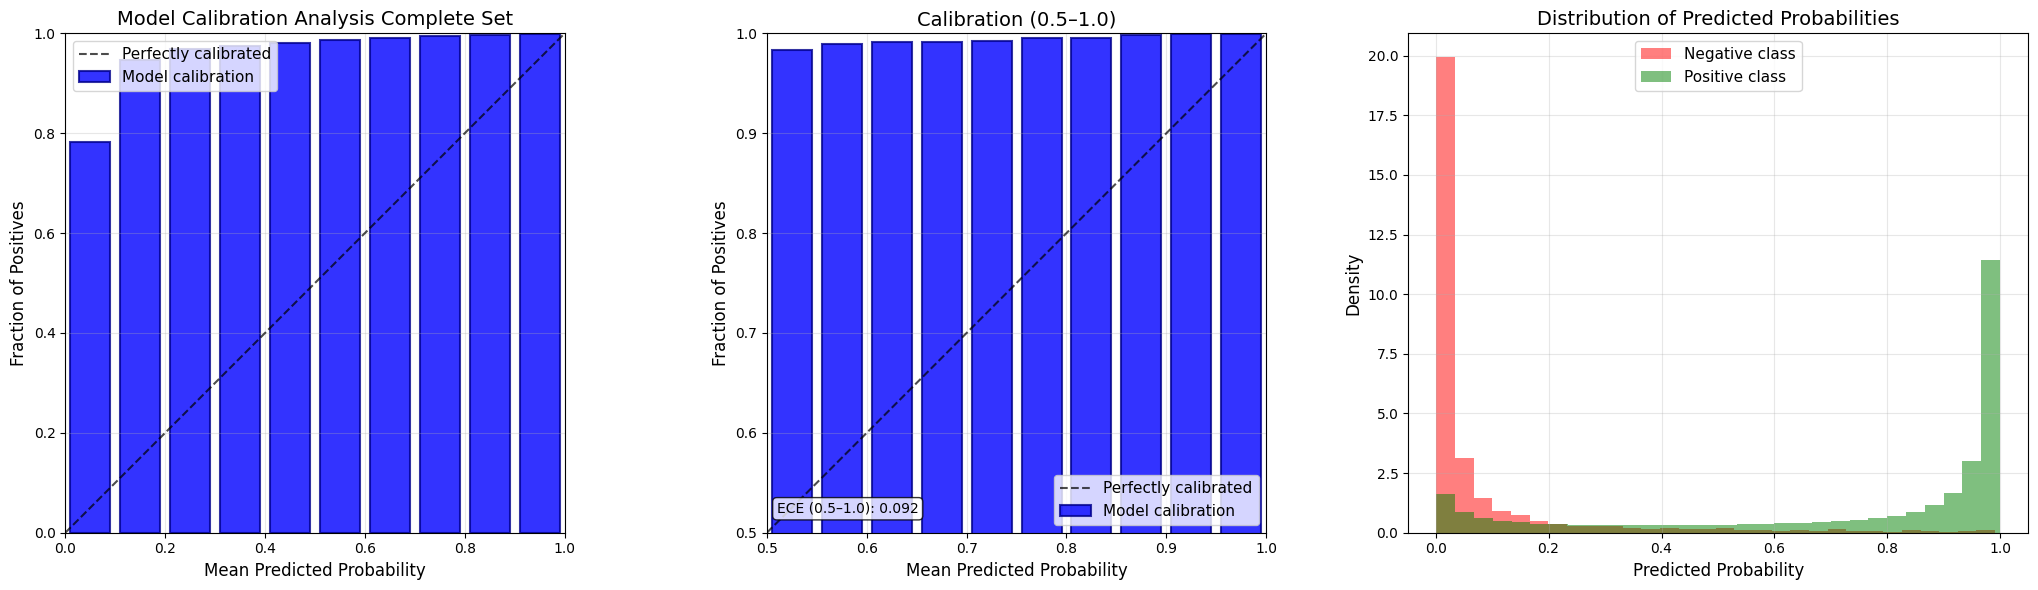


CALIBRATION METRICS:
Brier Score: 0.1817
Expected Calibration Error (ECE): 0.2580

Interpretation:
✓ Good calibration (Brier < 0.2)
⚠ High ECE (≥ 0.1) - Model confidence doesn't match accuracy

CONFIDENCE vs ACCURACY BY BINS:
Bin [0.00-0.05]: Samples=9706, Avg_Conf=0.020, Accuracy=0.731, Gap=0.711
Bin [0.05-0.10]: Samples=3745, Avg_Conf=0.073, Accuracy=0.915, Gap=0.842
Bin [0.10-0.15]: Samples=2680, Avg_Conf=0.124, Accuracy=0.940, Gap=0.816
Bin [0.15-0.20]: Samples=2197, Avg_Conf=0.174, Accuracy=0.954, Gap=0.780
Bin [0.20-0.25]: Samples=1848, Avg_Conf=0.224, Accuracy=0.964, Gap=0.740
Bin [0.25-0.30]: Samples=1717, Avg_Conf=0.275, Accuracy=0.976, Gap=0.701
Bin [0.30-0.35]: Samples=1645, Avg_Conf=0.324, Accuracy=0.970, Gap=0.645
Bin [0.35-0.40]: Samples=1658, Avg_Conf=0.376, Accuracy=0.981, Gap=0.606
Bin [0.40-0.45]: Samples=1671, Avg_Conf=0.425, Accuracy=0.977, Gap=0.552
Bin [0.45-0.50]: Samples=1718, Avg_Conf=0.476, Accuracy=0.984, Gap=0.508
Bin [0.50-0.55]: Samples=1705, Avg_Conf=0.5

In [4]:
test_csv_path = "/projects/retprogression/rgarridogarcia/clean_gradable_swinv2_resolution1024_oversample50_RetinaCropped_BrightnessFilter/test_results_20250917_085511/predictions_best_balanced_acc_model.csv"
val_csv_path = "/projects/retprogression/rgarridogarcia/clean_gradable_swinv2_resolution1024_oversample50_RetinaCropped_BrightnessFilter/val_results_20250917_085511/predictions_best_balanced_acc_model.csv"
complete_csv_path = "/projects/retprogression/rgarridogarcia/validation_results_20250917_082610/predictions_best_balanced_acc_model.csv"
output_directory = "/projects/retprogression/rgarridogarcia/calibration_plots"

# Create output directory if it doesn't exist
import os
if output_directory and not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Run the analysis
metrics = create_detailed_calibration_analysis(test_csv_path, output_directory, title="Model Calibration Analysis Test Set")
metrics = create_detailed_calibration_analysis(val_csv_path, output_directory, title="Model Calibration Analysis Val Set")
metrics = create_detailed_calibration_analysis(complete_csv_path, output_directory, title="Model Calibration Analysis Complete Set")